In [1]:

# %pip install torchmetrics
# pip install torchinfo
import os
import random
import torch
import numpy as np
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split, Subset
import torch.nn as nn
import torch.nn.functional as F
from torchmetrics.classification import MulticlassAccuracy
import torch.optim as optim
from tqdm import tqdm
import time
from torchinfo import summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Load dataset
seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
val_ratio = 0.1
generator = torch.Generator().manual_seed(seed)
use_reduced_data = True

transform = transforms.Compose([
    transforms.RandomResizedCrop((32, 32), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation((-30, 30)),
    # transforms.ColorJitter(),
    transforms.RandAugment(num_ops=2, magnitude=7),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transformTest = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

CIFAR10Dataset = torchvision.datasets.CIFAR10(root='.', download=True)
full_train_dataset = torchvision.datasets.CIFAR10(root='.', train=True, download=True, transform=None)
test_dataset = torchvision.datasets.CIFAR10(root='.', train=False, download=True, transform=transformTest)

if use_reduced_data:
    total_reduced_size = 10000
    selected_indices = torch.randperm(len(full_train_dataset), generator=generator)[:total_reduced_size]
else:
    selected_indices = torch.arange(len(full_train_dataset))

val_size = int(len(selected_indices) * val_ratio)
train_size = len(selected_indices) - val_size
train_indices, val_indices = random_split(selected_indices, [train_size, val_size], generator=generator)


train_dataset = Subset(
    torchvision.datasets.CIFAR10(root='.', train=True, download=False, transform=transform),
    train_indices.indices
)

val_dataset = Subset(
    torchvision.datasets.CIFAR10(root='.', train=True, download=False, transform=transformTest),
    val_indices.indices
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=os.cpu_count())
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=os.cpu_count())
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=os.cpu_count())


Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified


#Pretrained model ResNet101

In [3]:
import torch.nn as nn
from torchvision.models import resnet101

def get_resnet101(num_classes=10):
    model = resnet101(pretrained=True)

    # Adjust first conv and maxpool for CIFAR-10 input size (32x32)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()

    # Freeze all layers initially
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last half: layer3, layer4, and fc
    for name, param in model.named_parameters():
        if "layer3" in name or "layer4" in name or "fc" in name:
            param.requires_grad = True

    # Replace final classification layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# Instantiate and send to device
resnet101_model = get_resnet101()
resnet101_model.to(device)


/home/cse/miniforge3/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/cse/miniforge3/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentu

In [4]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8*8*64, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)
student = CNN().to(device)

In [5]:
def train(model, train_loader, val_loader, epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    model.to(device)
    results = []
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        start_time = time.time()

        for inputs, labels in (train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        val_acc, val_loss = validation(model, val_loader, device, show_metrics=False)
        scheduler.step()
        print(f"Epoch {epoch+1}/{epochs}({time.time() - start_time:.2f}s)  - accuracy: {train_acc:.4f}  - loss: {train_loss:.4f}  - val_accuracy: {val_acc:.4f}  - val_loss: {val_loss:.4f}")
        results.append([train_acc, train_loss, val_acc, val_loss])
    return results

def validation(model, test_loader, device, show_metrics=True):
    metric = MulticlassAccuracy(num_classes=10).to(device)
    model.eval()
    model.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    total_loss = 0.0

    with torch.no_grad():
        for inputs, labels in (test_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            metric.update(outputs, labels)
            total_loss += loss.item()

    accuracy_val = metric.compute().item()
    avg_loss = total_loss / len(test_loader)

    if show_metrics:
        print(f"Validation Accuracy: {accuracy_val:.4f} Loss: {avg_loss:.4f}")
    return accuracy_val, avg_loss


def train_knowledge_distillation(teacher, student, train_loader, val_loader, epochs, learning_rate, T, alpha, device):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(student.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    teacher.eval()  # Teacher set to evaluation mode
    student.train() # Student to train mode

    results = []

    for epoch in range(epochs):
        running_loss, correct, total = 0.0, 0, 0
        start_time = time.time()
        for inputs, labels in (train_loader):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.no_grad():
                teacher_logits = teacher(inputs)
            student_logits = student(inputs)

            label_loss = criterion(student_logits, labels)
            soft_prob = nn.functional.log_softmax(student_logits / T, dim=-1)
            soft_targets = nn.functional.softmax(teacher_logits / T, dim=-1)
            soft_targets_loss = F.kl_div(soft_prob, soft_targets, reduction='batchmean') * (T ** 2)
            loss = alpha * soft_targets_loss + (1 - alpha) * label_loss

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(student_logits, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        val_acc, val_loss = validation(student, val_loader, device, show_metrics=False)
        scheduler.step()
        print(f"Epoch {epoch+1}/{epochs}({time.time() - start_time:.2f}s) - accuracy: {train_acc:.4f}  - loss: {train_loss:.4f}  - val_accuracy: {val_acc:.4f}  - val_loss: {val_loss:.4f}")
        results.append([train_acc, train_loss, val_acc, val_loss])
    return results

epochs = 10
learning_rate = 1e-3
history_resnet101 = train(resnet101_model, train_loader, val_loader, epochs, learning_rate, device)
validation(resnet101_model, test_loader, device)

Epoch 1/10(95.66s)  - accuracy: 0.3404  - loss: 1.9437  - val_accuracy: 0.4622  - val_loss: 2.4479
Epoch 2/10(93.24s)  - accuracy: 0.4621  - loss: 1.6698  - val_accuracy: 0.5339  - val_loss: 1.5443
Epoch 3/10(94.95s)  - accuracy: 0.5174  - loss: 1.5647  - val_accuracy: 0.5025  - val_loss: 3.5105
Epoch 4/10(93.55s)  - accuracy: 0.5570  - loss: 1.4848  - val_accuracy: 0.6334  - val_loss: 1.3536
Epoch 5/10(94.65s)  - accuracy: 0.6083  - loss: 1.3869  - val_accuracy: 0.6817  - val_loss: 1.2433
Epoch 6/10(93.05s)  - accuracy: 0.6361  - loss: 1.3058  - val_accuracy: 0.7195  - val_loss: 1.1550
Epoch 7/10(94.84s)  - accuracy: 0.6759  - loss: 1.2413  - val_accuracy: 0.7506  - val_loss: 1.1022
Epoch 8/10(93.94s)  - accuracy: 0.7037  - loss: 1.1759  - val_accuracy: 0.7542  - val_loss: 1.1218
Epoch 9/10(95.31s)  - accuracy: 0.7283  - loss: 1.1183  - val_accuracy: 0.7763  - val_loss: 1.0372
Epoch 10/10(93.47s)  - accuracy: 0.7463  - loss: 1.0857  - val_accuracy: 0.7831  - val_loss: 1.0208
Validatio

(0.7731999754905701, 1.0401283882226153)

In [6]:

scratch_student = CNN().to(device)
history_scratch = train(scratch_student, train_loader, val_loader, epochs, learning_rate, device)
validation(scratch_student, test_loader, device)


Epoch 1/10(3.07s)  - accuracy: 0.3202  - loss: 1.9543  - val_accuracy: 0.4438  - val_loss: 1.6668
Epoch 2/10(3.02s)  - accuracy: 0.4074  - loss: 1.7802  - val_accuracy: 0.4903  - val_loss: 1.5808
Epoch 3/10(2.98s)  - accuracy: 0.4377  - loss: 1.7067  - val_accuracy: 0.5191  - val_loss: 1.5088
Epoch 4/10(3.01s)  - accuracy: 0.4727  - loss: 1.6467  - val_accuracy: 0.5718  - val_loss: 1.4456
Epoch 5/10(3.03s)  - accuracy: 0.5003  - loss: 1.5926  - val_accuracy: 0.5827  - val_loss: 1.4141
Epoch 6/10(3.04s)  - accuracy: 0.5174  - loss: 1.5639  - val_accuracy: 0.6087  - val_loss: 1.3706
Epoch 7/10(3.09s)  - accuracy: 0.5376  - loss: 1.5235  - val_accuracy: 0.6082  - val_loss: 1.3566
Epoch 8/10(3.03s)  - accuracy: 0.5534  - loss: 1.4803  - val_accuracy: 0.6206  - val_loss: 1.3333
Epoch 9/10(3.04s)  - accuracy: 0.5658  - loss: 1.4659  - val_accuracy: 0.6315  - val_loss: 1.3112
Epoch 10/10(3.07s)  - accuracy: 0.5697  - loss: 1.4538  - val_accuracy: 0.6340  - val_loss: 1.3092
Validation Accuracy

(0.6370999813079834, 1.3110564757304586)

In [7]:

T, alpha = 4, 0.8

history_kd = train_knowledge_distillation(resnet101_model, student, train_loader, val_loader, epochs, learning_rate, T=T, alpha=alpha, device=device)
validation(student, test_loader, device)


Epoch 1/10(38.52s) - accuracy: 0.3554  - loss: 1.1639  - val_accuracy: 0.4779  - val_loss: 1.6299
Epoch 2/10(38.75s) - accuracy: 0.4280  - loss: 0.9822  - val_accuracy: 0.5212  - val_loss: 1.5551
Epoch 3/10(37.22s) - accuracy: 0.4792  - loss: 0.8589  - val_accuracy: 0.5409  - val_loss: 1.5238
Epoch 4/10(38.60s) - accuracy: 0.5113  - loss: 0.7820  - val_accuracy: 0.5777  - val_loss: 1.4222
Epoch 5/10(38.70s) - accuracy: 0.5343  - loss: 0.7274  - val_accuracy: 0.6178  - val_loss: 1.3722
Epoch 6/10(38.70s) - accuracy: 0.5604  - loss: 0.6912  - val_accuracy: 0.6248  - val_loss: 1.3597
Epoch 7/10(38.69s) - accuracy: 0.5694  - loss: 0.6436  - val_accuracy: 0.6493  - val_loss: 1.3079
Epoch 8/10(37.25s) - accuracy: 0.5972  - loss: 0.6183  - val_accuracy: 0.6596  - val_loss: 1.2769
Epoch 9/10(38.58s) - accuracy: 0.6038  - loss: 0.6002  - val_accuracy: 0.6615  - val_loss: 1.2945
Epoch 10/10(38.61s) - accuracy: 0.6078  - loss: 0.5904  - val_accuracy: 0.6705  - val_loss: 1.2795
Validation Accuracy

(0.6660000085830688, 1.2582692739310537)

In [8]:
import matplotlib.pyplot as plt
def plot_history(history, title):
    # Unpack the history
    train_acc = [row[0] for row in history]
    train_loss = [row[1] for row in history]
    val_acc   = [row[2] for row in history]
    val_loss  = [row[3] for row in history]
    epochs = range(1, len(history) + 1)

    # Plotting
    plt.figure(figsize=(12, 5))

    # Subplot 1: Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_acc, label='Train Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy over Epochs')
    plt.legend()
    plt.grid(True)

    # Subplot 2: Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_loss, label='Train Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss over Epochs')
    plt.legend()
    plt.grid(True)
    plt.suptitle(f'{title}', fontsize=16)
    plt.tight_layout()
    plt.show()

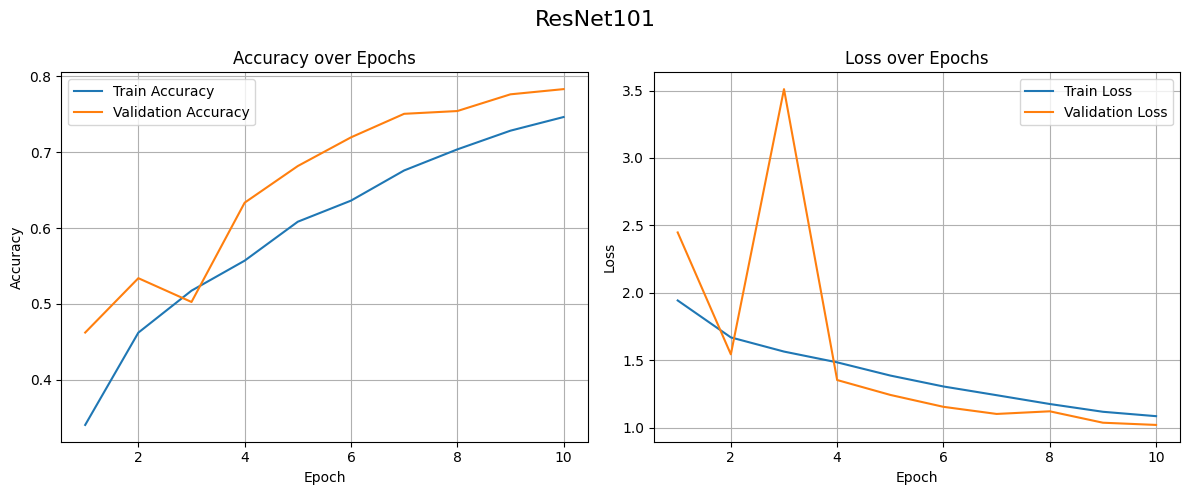

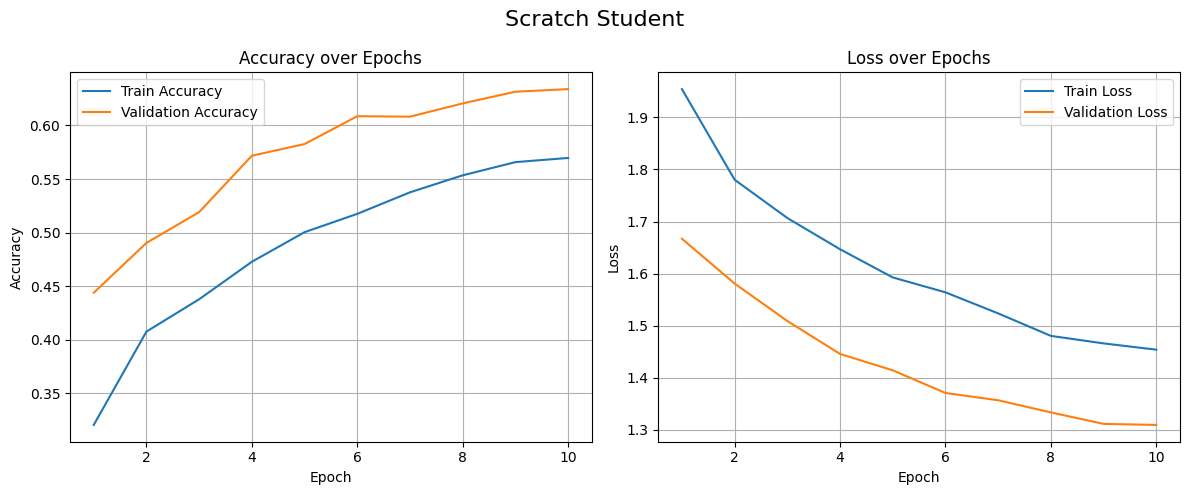

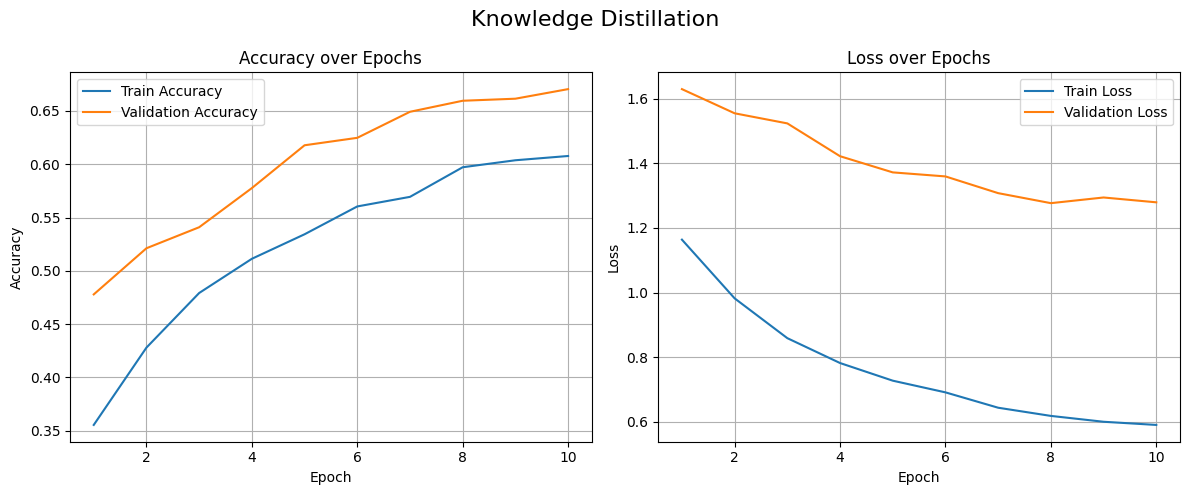

In [9]:
plot_history(history_resnet101, 'ResNet101')
plot_history(history_scratch, 'Scratch Student')
plot_history(history_kd, 'Knowledge Distillation')